In [ ]:
import numpy as np
from fontTools.varLib.avarPlanner import planOpticalSizeAxis

from matplotlib.colors import ListedColormap
from matplotlib.pyplot import figure


class DecisionTreeID3():
    def __init__(self):
        self.tree = None

    def fit(self, X, y, labels):
        self.tree = self._build_tree(X, y, labels, 1)
        return self.tree

    def _build_tree(self, X, y, labels, depth):
        ### 叶子节点该返回什么?
        if X.shape[0] == 0:
            return self._calc_majority_cnt(y)

        if len(np.unique(y)) == 1:
            return y[0]

        best_split_index, best_split_feature_name = self._best_split(X, y, labels)
        values = np.unique(X[:, best_split_index])
        tree = {
            best_split_feature_name:{}
        }
        for value in values:
            mask = X[:, best_split_index] == value
            X_sub = np.delete(X[mask], best_split_index, axis=1)
            labels_sub = np.delete(labels, best_split_index)
            y_sub = y[mask]

            ## 构造其他分支子树
            tree[best_split_feature_name][value] = self._build_tree(X_sub, y_sub, labels_sub, depth + 1)

        return tree

    def _best_split(self, X, y, feature_names):
        best_feature_index = self._best_feature_to_split(X, y)
        return best_feature_index, feature_names[best_feature_index]

    def _calc_type(self, y):
        types = np.unique(y)
        counts = []
        for type in types:
            mask = y == type
            counts.append(len(y[mask]))
        return np.array(counts)

    def _calc_entropy(self, y):
        counts = self._calc_type(y)
        probs = counts / len(y)
        probs = probs[probs > 0]
        return -np.sum(probs * np.log2(probs))

    def _information_gain(self, X_col, y):
        base_entropy = self._calc_entropy(y)
        values = np.unique(X_col)
        split_entropy = 0.0
        for value in values:
            mask = X_col == value
            sub_y = y[mask]
            split_entropy += len(sub_y) / len(y) * self._calc_entropy(sub_y)
        return base_entropy - split_entropy

    def _best_feature_to_split(self, X, y):
        num_features = X.shape[1]
        gains = [self._information_gain(X[:, i], y) for i in range(num_features)]
        return np.argmax(gains)

    def _calc_majority_cnt(self, y):
        counts = self._calc_type(y)
        return counts[np.argmax(counts)]

In [3]:

def clean_numpy_str(obj):
    if isinstance(obj, dict):
        return {clean_numpy_str(k): clean_numpy_str(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [clean_numpy_str(i) for i in obj]
    elif isinstance(obj, tuple):
        return tuple(clean_numpy_str(i) for i in obj)
    elif isinstance(obj, np.str_):
        return str(obj)
    else:
        return str(obj)

In [5]:
X = np.array([
        [0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 1, 0, 1],
        [0, 1, 1, 0],
        [0, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 0, 1],
        [1, 1, 1, 1],
        [1, 0, 1, 2],
        [1, 0, 1, 2],
        [2, 0, 1, 2],
        [2, 0, 1, 1],
        [2, 1, 0, 1],
        [2, 1, 0, 2],
        [2, 0, 0, 0]
    ])

y = np.array(['no', 'no', 'yes', 'yes', 'no', 'no', 'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'no'])
labels = np.array(['age', 'work', 'home', 'loan'])
tree = DecisionTreeID3()
tree.fit(X, y, labels)
import json
print(json.dumps(clean_numpy_str(tree.tree), ensure_ascii=False, indent=2))

{
  "home": {
    "0": {
      "work": {
        "0": "no",
        "1": "yes"
      }
    },
    "1": "yes"
  }
}


In [8]:
import numpy as np

class DecisionTreeCART():
    def __init__(self):
        self.tree = None

    def fit(self, X, y, labels):
        self.tree = self._build_tree(X, y, labels, 1)
        return self.tree

    def _build_tree(self, X, y, labels, depth):
        ### 叶子节点该返回什么?
        if X.shape[0] == 0:
            return self._calc_majority_cnt(y)

        if len(np.unique(y)) == 1:
            return y[0]

        best_split_index, best_split_feature_name = self._best_split(X, y, labels)
        values = np.unique(X[:, best_split_index])
        tree = {
            best_split_feature_name:{}
        }
        for value in values:
            mask = X[:, best_split_index] == value
            X_sub = np.delete(X[mask], best_split_index, axis=1)
            labels_sub = np.delete(labels, best_split_index)
            y_sub = y[mask]

            ## 构造其他分支子树
            tree[best_split_feature_name][value] = self._build_tree(X_sub, y_sub, labels_sub, depth + 1)

        return tree

    def _best_split(self, X, y, feature_names):
        best_feature_index = self._best_feature_to_split(X, y)
        return best_feature_index, feature_names[best_feature_index]

    def _calc_type(self, y):
        types = np.unique(y)
        counts = []
        for type in types:
            mask = y == type
            counts.append(len(y[mask]))
        return np.array(counts)

    def _calc_gini(self, y):
        if len(y) == 0:
            return 0
        counts = self._calc_type(y)
        probs = counts / len(y)
        gini = 1 - np.sum(probs**2)
        return gini

    def _calc_split_gini(self, X_col, y):
        types = np.unique(X_col)
        gini_split = 0
        for type in types:
            mask = X_col == type
            y_sub = y[mask]
            gini_split += len(y_sub)/len(y) * self._calc_gini(y_sub)
        return gini_split

    def _best_feature_to_split(self, X, y):
        num_features = X.shape[1]
        gains = [self._calc_split_gini(X[:, i], y) for i in range(num_features)]
        return np.argmin(gains)

    def _calc_majority_cnt(self, y):
        counts = self._calc_type(y)
        return counts[np.argmax(counts)]

In [9]:
X = np.array([
        [0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 1, 0, 1],
        [0, 1, 1, 0],
        [0, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 0, 1],
        [1, 1, 1, 1],
        [1, 0, 1, 2],
        [1, 0, 1, 2],
        [2, 0, 1, 2],
        [2, 0, 1, 1],
        [2, 1, 0, 1],
        [2, 1, 0, 2],
        [2, 0, 0, 0]
    ])

y = np.array(['no', 'no', 'yes', 'yes', 'no', 'no', 'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'no'])
labels = np.array(['age', 'work', 'home', 'loan'])
tree = DecisionTreeCART()
tree.fit(X, y, labels)
import json
print(json.dumps(clean_numpy_str(tree.tree), ensure_ascii=False, indent=2))

{
  "home": {
    "0": {
      "work": {
        "0": "no",
        "1": "yes"
      }
    },
    "1": "yes"
  }
}


In [36]:
### 基于gini方法 增加自动识别X特征是否是连续值或者离散值
import numpy as np

class DecisionTreeCART():
    def __init__(self, max_depth=None, min_samples_split=2):
        self.feature_names = None
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def fit(self, X, y, feature_names):
        X, y = np.array(X), np.array(y)
        is_discrete = self._auto_detect_feature_types(X, 3)
        self.tree = self._build_tree(X, y, feature_names, is_discrete, 1)
        self.feature_names = feature_names
        return self.tree

    def predict(self, X):
        """对多个样本进行预测"""
        X = np.array(X)
        return [self._predict_sample(x, self.tree) for x in X]

    def _predict_sample(self, x, tree):
        """递归预测单个样本"""
        if not isinstance(tree, dict):
            return tree  # 叶子节点

        feature_name = next(iter(tree))  # 当前节点分裂特征
        branches = tree[feature_name]

        # 找出该特征在样本中的索引
        # 注意：需要保持 feature_name 与训练时 labels 对应顺序一致
        try:
            feature_index = self.feature_names.index(feature_name)
        except ValueError:
            raise ValueError(f"特征 '{feature_name}' 不存在于训练 feature_names 中")

        feature_val = x[feature_index]

        # 遍历子分支进行递归
        for branch_key, subtree in branches.items():
            if isinstance(branch_key, str) and branch_key.startswith('<='):
                # 连续特征分支
                threshold = float(branch_key.split('<=')[-1])
                if float(feature_val) <= threshold:
                    return self._predict_sample(x, subtree)
            elif isinstance(branch_key, str) and branch_key.startswith('>'):
                threshold = float(branch_key.split('>')[-1])
                if float(feature_val) > threshold:
                    return self._predict_sample(x, subtree)
            else:
                # 离散特征匹配
                if feature_val == branch_key:
                    return self._predict_sample(x, subtree)

        # 如果没找到匹配的分支（可能是未知值），可返回 None 或多数类兜底
        return None

    def _build_tree(self, X, y, feature_names, is_discrete, depth, default_label=None):
        ### 叶子节点该返回什么?
        if X.shape[0] == 0 or len(y) == 0:
            ## 在 X.shape[0] == 0 时，无法直接通过当前 y 计算多数类，返回上一层的多数类
            return default_label

        if X.shape[1] == 0:
            return self._calc_majority_cnt(y)

        if len(np.unique(y)) == 1:
            return y[0]

        if self.max_depth is not None and depth > self.max_depth:
            return self._calc_majority_cnt(y)

        if X.shape[0] < self.min_samples_split:
            return self._calc_majority_cnt(y)

        current_majority = self._calc_majority_cnt(y)

        best_split_index, best_split_feature_name, gini_info = self._best_split(X, y, feature_names, is_discrete)
        tree = {
            best_split_feature_name:{}
        }
        if gini_info['type'] == 'discrete':
            values = np.unique(X[:, best_split_index])
            for value in values:
                mask = X[:, best_split_index] == value
                X_sub = np.delete(X[mask], best_split_index, axis=1)
                feature_names_sub = np.delete(feature_names, best_split_index)
                is_discrete_sub = np.delete(is_discrete, best_split_index)
                y_sub = y[mask]

                ## 构造其他分支子树
                tree[best_split_feature_name][value] = self._build_tree(X_sub, y_sub, feature_names_sub, is_discrete_sub, depth + 1, default_label = current_majority)
        else:
            threshold = gini_info['threshold']
            left_mask = X[:, best_split_index] <= threshold
            right_mask = ~left_mask

            left_X_sub = X[left_mask, :]
            left_y_sub = y[left_mask]
            right_X_sub = X[right_mask, :]
            right_y_sub = y[right_mask]
            ## 构造其他分支子树
            tree[best_split_feature_name][f"<= {threshold}"] = self._build_tree(left_X_sub, left_y_sub, feature_names, is_discrete, depth + 1, default_label = current_majority)
            tree[best_split_feature_name][f"> {threshold}"] = self._build_tree(right_X_sub, right_y_sub, feature_names, is_discrete, depth + 1, default_label = current_majority)

        return tree

    def _best_split(self, X, y, feature_names, is_discrete):
        best_feature_index, gini_info = self._best_feature_to_split(X, y, is_discrete)
        return best_feature_index, feature_names[best_feature_index], gini_info

    def _best_feature_to_split(self, X, y, is_discrete):
        num_features = X.shape[1]
        gini_infos = []
        gini_score = []
        for i in range(num_features):
            if is_discrete[i]:
                gini_infos.append(self._calc_split_gini(X[:, i], y))
            else:
                gini_infos.append(self._calc_split_gini_continuous(X[:, i], y))
            gini_score.append(gini_infos[i]["gini"])

        best_gini_index = np.argmin(gini_score)
        return best_gini_index, gini_infos[np.argmin(gini_score)]

    def _calc_type(self, y):
        types = np.unique(y)
        counts = []
        for type in types:
            mask = y == type
            counts.append(len(y[mask]))
        return np.array(counts)

    def _calc_gini(self, y):
        if len(y) == 0:
            return 0
        counts = self._calc_type(y)
        probs = counts / len(y)
        gini = 1 - np.sum(probs**2)
        return gini

    def _calc_split_gini(self, X_col, y):
        types = np.unique(X_col)
        gini_split = 0
        for type in types:
            mask = X_col == type
            y_sub = y[mask]
            gini_split += len(y_sub)/len(y) * self._calc_gini(y_sub)
        return {
            "type": "discrete",
            "gini": gini_split
        }

    def _calc_split_gini_continuous(self, X_col, y):
        sort_index = np.argsort(X_col)
        X_sorted = X_col[sort_index]
        y_sorted = y[sort_index]
        unique_vals = np.unique(X_sorted)
        if len(unique_vals) == 1:
            # 所有值都相同，无法分割,不能计算gini值
            return {
                "type": "continuous",
                "gini": float("inf"), ## 代表无穷大
                "threshold": None
            }

        thresholds = (X_sorted[:-1] + X_sorted[1:]) / 2
        best_gini = float("inf")
        best_threshold = None
        for threshold in thresholds:
            left_mask = (X_sorted <= threshold)
            right_mask = ~left_mask
            y_left_sub = y[left_mask]
            y_right_sub = y[right_mask]
            gini = len(y_left_sub)/len(y_sorted) * self._calc_gini(y_left_sub) + len(y_right_sub)/len(y_sorted) * self._calc_gini(y_right_sub)
            if gini < best_gini:
                best_gini = gini
                best_threshold = threshold
            if best_gini == 0:
                break

        return {
            "type": "continuous",
            "gini": best_gini,
            "threshold": best_threshold
        }

    def _calc_majority_cnt(self, y):
        """计算最大类别"""
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def _auto_detect_feature_types(self, X, max_threshold=3):
        """自动检测是特征离散型 还是连续型"""
        is_discrete = []
        if isinstance(X, np.ndarray):
            for i in range(X.shape[1]):
                col = X[:, i]
                if np.issubdtype(col.dtype, np.number):
                    num_unique = len(np.unique(col))
                    is_discrete.append(num_unique <= max_threshold)
                else:
                    is_discrete.append(True)
        return np.array(is_discrete)


In [37]:
from sklearn.datasets import load_iris
iris_data = load_iris()
dtc = DecisionTreeCART()
dtc.fit(iris_data.data, iris_data.target, iris_data.feature_names)

{'petal length (cm)': {'<= 1.9': np.int64(0),
  '> 1.9': {'sepal length (cm)': {'<= 6.2': {'petal length (cm)': {'<= 4.7': {'sepal width (cm)': {'<= 3.0': {'petal width (cm)': {'<= 1.5': np.int64(1),
          '> 1.5': np.int64(2)}},
        '> 3.0': np.int64(1)}},
      '> 4.7': {'sepal length (cm)': {'<= 5.75': np.int64(2),
        '> 5.75': {'sepal width (cm)': {'<= 2.6500000000000004': np.int64(2),
          '> 2.6500000000000004': {'sepal length (cm)': {'<= 5.8': np.int64(2),
            '> 5.8': {'sepal length (cm)': {'<= 5.9': {'sepal width (cm)': {'<= 3.1': np.int64(2),
                '> 3.1': np.int64(1)}},
              '> 5.9': {'sepal width (cm)': {'<= 2.75': np.int64(1),
                '> 2.75': np.int64(2)}}}}}}}}}}}},
    '> 6.2': {'sepal width (cm)': {'<= 2.8': {'sepal width (cm)': {'<= 2.5': {'petal length (cm)': {'<= 4.95': np.int64(1),
          '> 4.95': np.int64(2)}},
        '> 2.5': {'sepal length (cm)': {'<= 6.3': np.int64(2),
          '> 6.3': {'sepal width 

In [39]:
y_pred = dtc.predict(iris_data.data)
np.unique(y_pred, return_counts=True)

(array([0, 1, 2]), array([50, 50, 50]))

In [45]:
next(iter(dtc.tree))

'petal length (cm)'

In [50]:
list(dtc.tree['petal length (cm)'].items())

[('<= 1.9', np.int64(0)),
 ('> 1.9',
  {'sepal length (cm)': {'<= 6.2': {'petal length (cm)': {'<= 4.7': {'sepal width (cm)': {'<= 3.0': {'petal width (cm)': {'<= 1.5': np.int64(1),
          '> 1.5': np.int64(2)}},
        '> 3.0': np.int64(1)}},
      '> 4.7': {'sepal length (cm)': {'<= 5.75': np.int64(2),
        '> 5.75': {'sepal width (cm)': {'<= 2.6500000000000004': np.int64(2),
          '> 2.6500000000000004': {'sepal length (cm)': {'<= 5.8': np.int64(2),
            '> 5.8': {'sepal length (cm)': {'<= 5.9': {'sepal width (cm)': {'<= 3.1': np.int64(2),
                '> 3.1': np.int64(1)}},
              '> 5.9': {'sepal width (cm)': {'<= 2.75': np.int64(1),
                '> 2.75': np.int64(2)}}}}}}}}}}}},
    '> 6.2': {'sepal width (cm)': {'<= 2.8': {'sepal width (cm)': {'<= 2.5': {'petal length (cm)': {'<= 4.95': np.int64(1),
          '> 4.95': np.int64(2)}},
        '> 2.5': {'sepal length (cm)': {'<= 6.3': np.int64(2),
          '> 6.3': {'sepal width (cm)': {'<= 2.75':

In [66]:
## 如果是回归模型,则修改方法如下:
import numpy as np

class DecisionTreePlus:
    def __init__(self, mode='classification', max_depth=None, min_samples_split=2, max_unique_threshold=3):
        assert mode in ['classification', 'regression']
        self.mode = mode
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_unique_threshold = max_unique_threshold
        self.tree = None
        self.labels = None

    def fit(self, X, y, labels):
        X, y = np.array(X), np.array(y)
        self.labels = [str(l) for l in labels]
        is_discrete = self._auto_detect_feature_types(X)
        self.tree = self._build_tree(X, y, self.labels, is_discrete, depth=1)
        return self.tree

    def predict(self, X):
        X = np.array(X)
        return [self._predict_sample(x, self.tree) for x in X]

    def _predict_sample(self, x, tree):
        if not isinstance(tree, dict):
            return tree  # 叶子节点

        feature_name = str(next(iter(tree)))
        branches = tree[feature_name]

        if feature_name not in self.labels:
            return None

        feature_index = self.labels.index(feature_name)
        feature_val = x[feature_index]

        for branch_key, subtree in branches.items():
            if isinstance(branch_key, str):
                if branch_key.startswith('<='):
                    threshold = float(branch_key.split('<=')[-1])
                    if float(feature_val) <= threshold:
                        return self._predict_sample(x, subtree)
                elif branch_key.startswith('>'):
                    threshold = float(branch_key.split('>')[-1])
                    if float(feature_val) > threshold:
                        return self._predict_sample(x, subtree)
                else:
                    # 离散值判断
                    if str(feature_val) == branch_key:
                        return self._predict_sample(x, subtree)
            else:
                # 安全兜底
                if feature_val == branch_key:
                    return self._predict_sample(x, subtree)

        # 如果没有找到匹配路径，默认返回 None
        return None


    def _build_tree(self, X, y, labels, is_discrete, depth, default_label=None):
        if X.shape[0] == 0 or len(y) == 0:
            return default_label

        if X.shape[1] == 0:
            return self._calc_leaf_output(y)

        if self.mode == 'classification' and len(np.unique(y)) == 1:
            return y[0]

        if self.max_depth is not None and depth > self.max_depth:
            return self._calc_leaf_output(y)

        if X.shape[0] < self.min_samples_split:
            return self._calc_leaf_output(y)

        current_leaf = self._calc_leaf_output(y)

        best_index, best_feature, split_info = self._best_split(X, y, labels, is_discrete)
        tree = {best_feature: {}}

        if split_info['type'] == 'discrete':
            for val in np.unique(X[:, best_index]):
                mask = X[:, best_index] == val
                X_sub = np.delete(X[mask], best_index, axis=1)
                y_sub = y[mask]
                labels_sub = np.delete(labels, best_index)
                is_discrete_sub = np.delete(is_discrete, best_index)
                tree[best_feature][f"{val}"] = self._build_tree(
                    X_sub, y_sub, labels_sub, is_discrete_sub, depth + 1, default_label=current_leaf)
        else:
            threshold = split_info['threshold']
            left_mask = X[:, best_index] <= threshold
            right_mask = ~left_mask
            tree[best_feature][f"<= {threshold}"] = self._build_tree(
                X[left_mask], y[left_mask], labels, is_discrete, depth + 1, default_label=current_leaf)
            tree[best_feature][f"> {threshold}"] = self._build_tree(
                X[right_mask], y[right_mask], labels, is_discrete, depth + 1, default_label=current_leaf)

        return tree

    def _best_split(self, X, y, labels, is_discrete):
        best_index, info = self._best_feature_to_split(X, y, is_discrete)
        return best_index, labels[best_index], info

    def _best_feature_to_split(self, X, y, is_discrete):
        infos, scores = [], []
        for i in range(X.shape[1]):
            if is_discrete[i]:
                info = self._calc_split_discrete(X[:, i], y)
            else:
                info = self._calc_split_continuous(X[:, i], y)
            infos.append(info)
            scores.append(info["score"])
        best_idx = np.argmin(scores)
        return best_idx, infos[best_idx]

    def _calc_split_discrete(self, X_col, y):
        unique_vals = np.unique(X_col)
        weighted_score = 0
        for val in unique_vals:
            mask = X_col == val
            y_sub = y[mask]
            weighted_score += len(y_sub) / len(y) * self._calc_score(y_sub)
        return {"type": "discrete", "score": weighted_score}

    def _calc_split_continuous(self, X_col, y):
        sort_idx = np.argsort(X_col)
        X_sorted, y_sorted = X_col[sort_idx], y[sort_idx]
        unique_vals = np.unique(X_sorted)
        if len(unique_vals) == 1:
            return {"type": "continuous", "score": float('inf'), "threshold": None}
        thresholds = (X_sorted[:-1] + X_sorted[1:]) / 2
        best_score = float("inf")
        best_threshold = None
        for t in thresholds:
            left_mask = X_sorted <= t
            right_mask = ~left_mask
            y_left, y_right = y_sorted[left_mask], y_sorted[right_mask]
            score = (
                len(y_left) / len(y_sorted) * self._calc_score(y_left) +
                len(y_right) / len(y_sorted) * self._calc_score(y_right)
            )
            if score < best_score:
                best_score = score
                best_threshold = t
        return {"type": "continuous", "score": best_score, "threshold": best_threshold}

    def _calc_score(self, y):
        if self.mode == 'classification':
            values, counts = np.unique(y, return_counts=True)
            probs = counts / len(y)
            return 1 - np.sum(probs ** 2)
        else:
            if len(y) == 0:
                return 0
            mean = np.mean(y)
            return np.mean((y - mean) ** 2)

    def _calc_leaf_output(self, y):
        if self.mode == 'classification':
            values, counts = np.unique(y, return_counts=True)
            return values[np.argmax(counts)]
        else:
            return float(np.mean(y))

    def _auto_detect_feature_types(self, X):
        is_discrete = []
        for i in range(X.shape[1]):
            col = X[:, i]
            if np.issubdtype(col.dtype, np.number):
                is_discrete.append(len(np.unique(col)) <= self.max_unique_threshold)
            else:
                is_discrete.append(True)
        return np.array(is_discrete)

In [67]:
X = [
    ['成年', '男', 1, '篮球'],
    ['未成年', '男', 2, '足球'],
    ['成年', '女', 1, '篮球']
]
y = [1, 0, 1]
labels = ['年龄', '性别', '等级', '爱好']

clf = DecisionTreePlus(mode='classification', max_depth=3)
clf.fit(X, y, labels)
print(clf.predict(X))


[np.int64(1), np.int64(0), np.int64(1)]


In [ ]:
X = [
    [25, 1],
    [40, 2],
    [35, 1],
    [25, 2],
    [55, 1],
    [15, 1],
    [5, 2]
]
y = [100.0, 300.0, 200., 300, 200, 100, 300]
labels = ['年龄', '等级']

reg = DecisionTreePlus(mode='regression', max_depth=5)

reg.fit(X, y, labels)

print(reg.tree)
print(reg.predict([[30, 1], [45, 2]]))

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris()
dtp = DecisionTreePlus(mode='classification', max_depth=5)
dtp.fit(iris.data, iris.target, iris.feature_names)
print(dtp.tree)
print(iris.target_names[dtp.predict(iris.data)])

In [79]:
import json
print(json.dumps(clean_numpy_str(dtp.tree), ensure_ascii=False, indent=2))

{
  "petal length (cm)": {
    "<= 1.9": "0",
    "> 1.9": {
      "petal width (cm)": {
        "<= 1.7": {
          "petal length (cm)": {
            "<= 4.9": {
              "petal width (cm)": {
                "<= 1.6": "1",
                "> 1.6": "2"
              }
            },
            "> 4.9": {
              "petal width (cm)": {
                "<= 1.5": "2",
                "> 1.5": {
                  "sepal length (cm)": {
                    "<= 6.95": "1",
                    "> 6.95": "2"
                  }
                }
              }
            }
          }
        },
        "> 1.7": {
          "petal length (cm)": {
            "<= 4.8": {
              "sepal length (cm)": {
                "<= 5.95": "1",
                "> 5.95": "2"
              }
            },
            "> 4.8": "2"
          }
        }
      }
    }
  }
}


# 实验分析

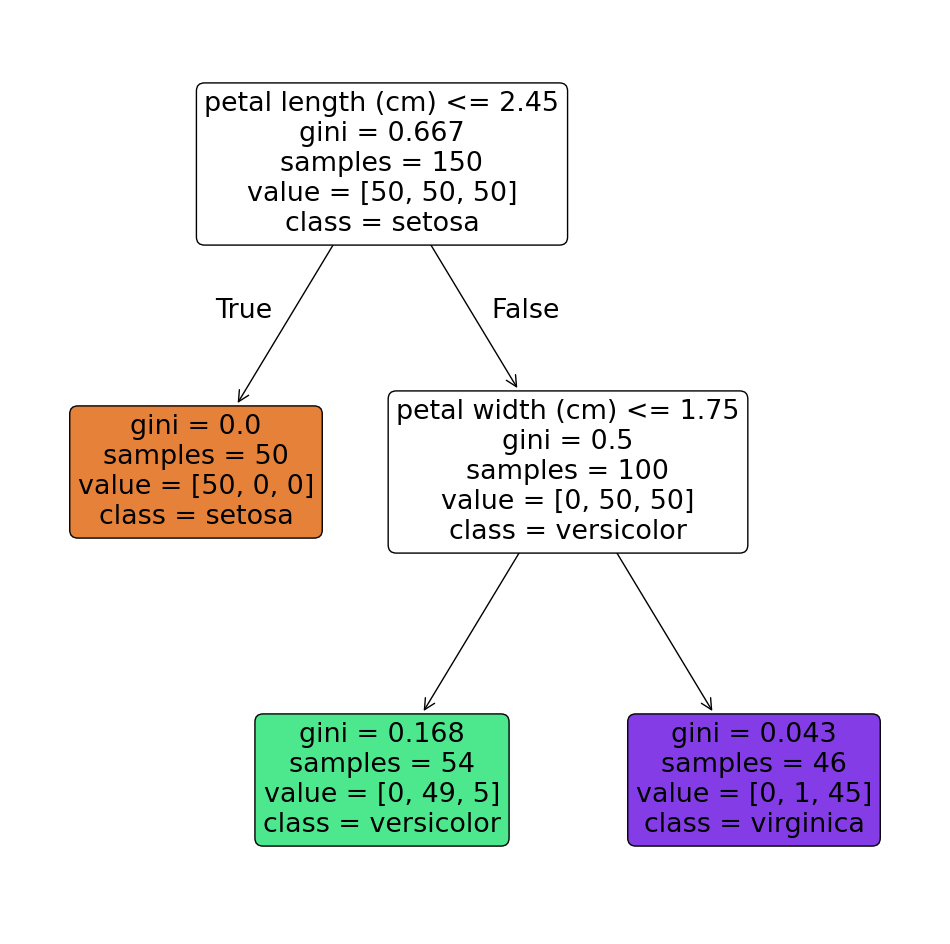

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.datasets import load_iris
from matplotlib import pyplot as plt
import numpy as np

iris = load_iris()
X = iris.data
y = iris.target
clf = DecisionTreeClassifier(max_depth=2)
clf.fit(X, y)

plt.figure(figsize=(12, 12), dpi=100)
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, rounded=True)
plt.show()



In [8]:
print(iris.target_names)
print((iris.feature_names))
X[55], clf.predict_proba(np.array([X[55]]))

['setosa' 'versicolor' 'virginica']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


(array([5.7, 2.8, 4.5, 1.3]), array([[0.        , 0.90740741, 0.09259259]]))

In [9]:
X[110], clf.predict_proba(np.array([X[110]]))

(array([6.5, 3.2, 5.1, 2. ]), array([[0.        , 0.02173913, 0.97826087]]))

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.datasets import load_iris
from matplotlib import pyplot as plt

iris = load_iris()
X = iris.data[:, 2:]
y = iris.target
clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X, y)
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


[Text(0.375, 0.875, 'sepal length (cm) <= 2.45\ngini = 0.667\nsamples = 150\nvalue = [50, 50, 50]\nclass = setosa'),
 Text(0.25, 0.625, 'gini = 0.0\nsamples = 50\nvalue = [50, 0, 0]\nclass = setosa'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'sepal width (cm) <= 1.75\ngini = 0.5\nsamples = 100\nvalue = [0, 50, 50]\nclass = versicolor'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'sepal length (cm) <= 4.95\ngini = 0.168\nsamples = 54\nvalue = [0, 49, 5]\nclass = versicolor'),
 Text(0.125, 0.125, 'gini = 0.041\nsamples = 48\nvalue = [0, 47, 1]\nclass = versicolor'),
 Text(0.375, 0.125, 'gini = 0.444\nsamples = 6\nvalue = [0, 2, 4]\nclass = virginica'),
 Text(0.75, 0.375, 'sepal length (cm) <= 4.85\ngini = 0.043\nsamples = 46\nvalue = [0, 1, 45]\nclass = virginica'),
 Text(0.625, 0.125, 'gini = 0.444\nsamples = 3\nvalue = [0, 1, 2]\nclass = virginica'),
 Text(0.875, 0.125, 'gini = 0.0\nsamples = 43\nvalue = [0, 0, 43]\nclass = virginica')]

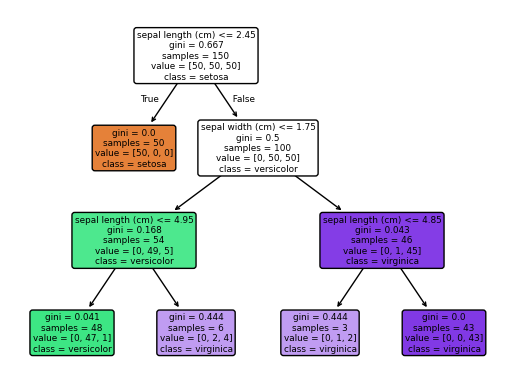

In [20]:
plot_tree(clf, feature_names=iris.feature_names[:2], class_names=iris.target_names, filled=True, rounded=True)

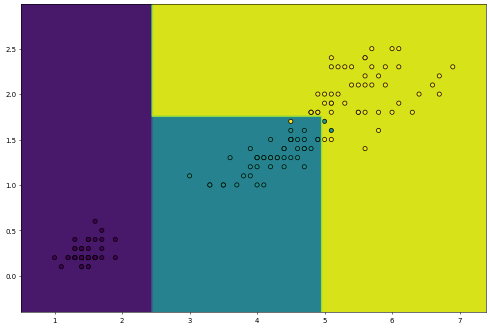

In [21]:
x0_min, x0_max = X[:, 0].min() - .5, X[:, 0].max() + .5
x1_min, x1_max = X[:, 1].min() - 0.5, X[:, 1].max() + .5
XX, YY = np.meshgrid(np.arange(x0_min, x0_max, 0.01), np.arange(x1_min, x1_max, 0.01))
grid = np.c_[XX.ravel(), YY.ravel()]
plt.figure(figsize=(12, 8), dpi=50)
Z = clf.predict(grid).reshape(XX.shape)
plt.contour(XX, YY, Z)
plt.contourf(XX, YY, Z)
plt.scatter(X[:, 0], X[:, 1], cmap='viridis', c=y, edgecolors='k')
plt.show()


In [22]:
## 概率预测
print(clf.predict_proba([[2.44, 4.85]]))
print(clf.predict_proba([[2.45, 4.85]]))

print(clf.predict_proba([[1.76, 4.86]]))
print(clf.predict_proba([[1.75, 4.86]]))

[[1. 0. 0.]]
[[0.         0.33333333 0.66666667]]
[[1. 0. 0.]]
[[1. 0. 0.]]


### 从上图可以看出,概率是固定的,在不同的区间内的预测概率是相同的

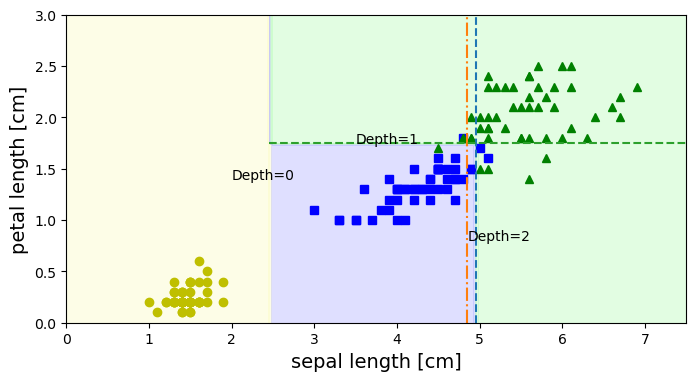

In [23]:
from matplotlib.colors import ListedColormap
def plot_decision_boundary(clf, X, y, axes=[0, 7.5, 0, 3], iris=True, legend=False, plot_training=True):
    x1 = np.linspace(axes[0], axes[1], 100)
    x2 = np.linspace(axes[2], axes[3], 100)
    xx1, xx2 = np.meshgrid(x1, x2)
    X_new = np.c_[xx1.ravel(), xx2.ravel()]
    y_pred = clf.predict(X_new).reshape(xx1.shape)

    ## 设置颜色
    custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    if not iris:
        custom_map2 = ListedColormap(['#7d7d58', '#4c4c7f', '#507d50'])
        plt.contourf(x1, x2, y_pred, alpha=0.8, cmap=custom_map2)
    if plot_training:
        plt.plot(X[:, 0][y==0], X[:, 1][y==0], 'yo', label='Iris-Setosa')
        plt.plot(X[:, 0][y==1], X[:, 1][y==1], 'bs', label='Iris-Versicolor')
        plt.plot(X[:, 0][y==2], X[:, 1][y==2], 'g^', label='Iris-Virginica')
    if iris:
        plt.xlabel('sepal length [cm]', fontsize=14)
        plt.ylabel('petal length [cm]', fontsize=14)
    else:
        plt.xlabel(r'$x_1$', fontsize=18)
        plt.ylabel(r'$x_2$', fontsize=18, rotation=0)

    if legend:
        plt.legend(loc='lower right', fontsize=14)

plt.figure(figsize=(8, 4))
plot_decision_boundary(clf, X, y)
plt.plot([4.95, 4.95], [0, 3], linestyle='--')
plt.plot([4.85, 4.85], [0, 3], linestyle='-.')
plt.plot([2.45, 7.5], [1.75, 1.75], linestyle='--')
plt.text(2.0, 1.4, 'Depth=0')
plt.text(3.5, 1.75, 'Depth=1')
plt.text(4.85, 0.8, 'Depth=2')

plt.show()


### 预剪枝
- max_depth 最大深度
- min_samples_split 最小样本数
- min_samples_leaf 最小样本叶子节点数
- max_leaf_nodes 最大叶子节点数

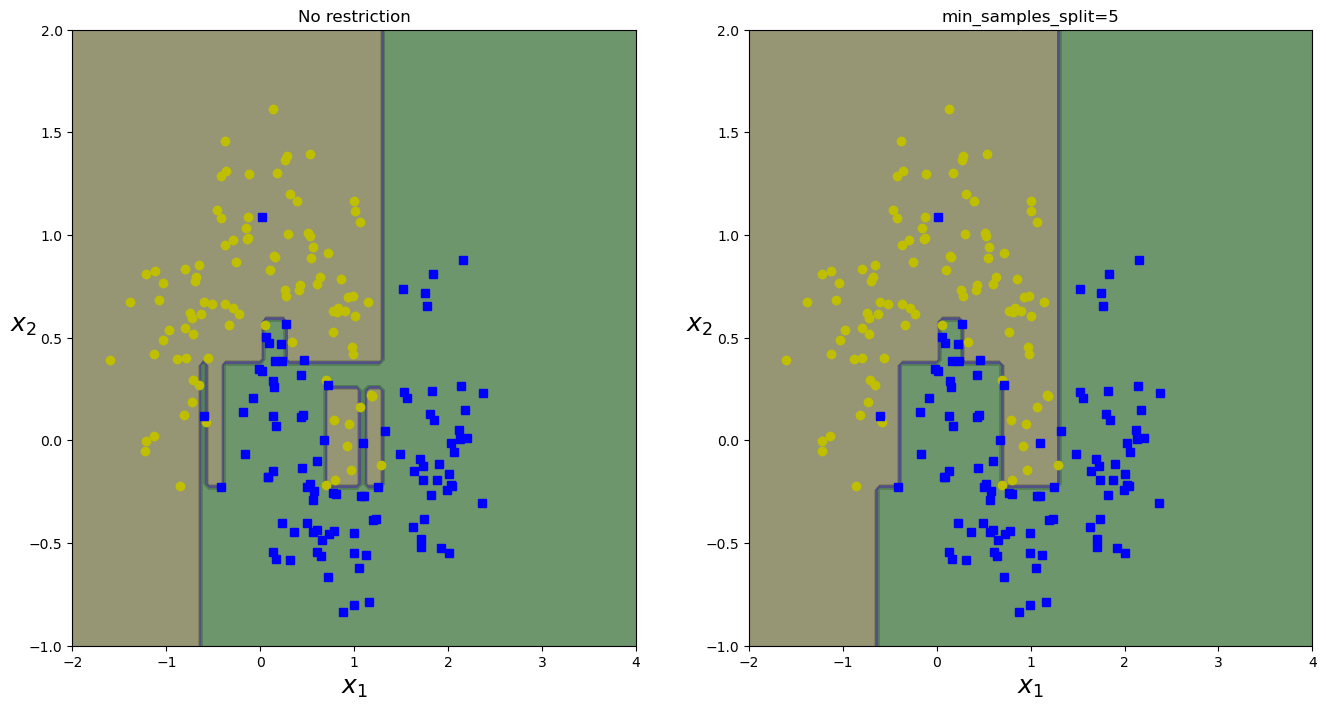

In [28]:
### 预剪枝
from matplotlib import pyplot as plt
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier

X, y = make_moons(n_samples=200, noise=0.25, random_state=42)

tree1 = DecisionTreeClassifier()
tree2 = DecisionTreeClassifier(min_samples_split=6)
tree1.fit(X, y)
tree2.fit(X, y)
plt.figure(figsize=(16, 8), dpi=100)
plt.subplot(121)
plt.title('No restriction')
plot_decision_boundary(tree1, X, y, axes=[-2, 4, -1, 2], iris=False)
plt.subplot(122)
plt.title('min_samples_split=5')
plot_decision_boundary(tree2, X, y, axes=[-2, 4, -1, 2], iris=False)
plt.show()


### 数据敏感度

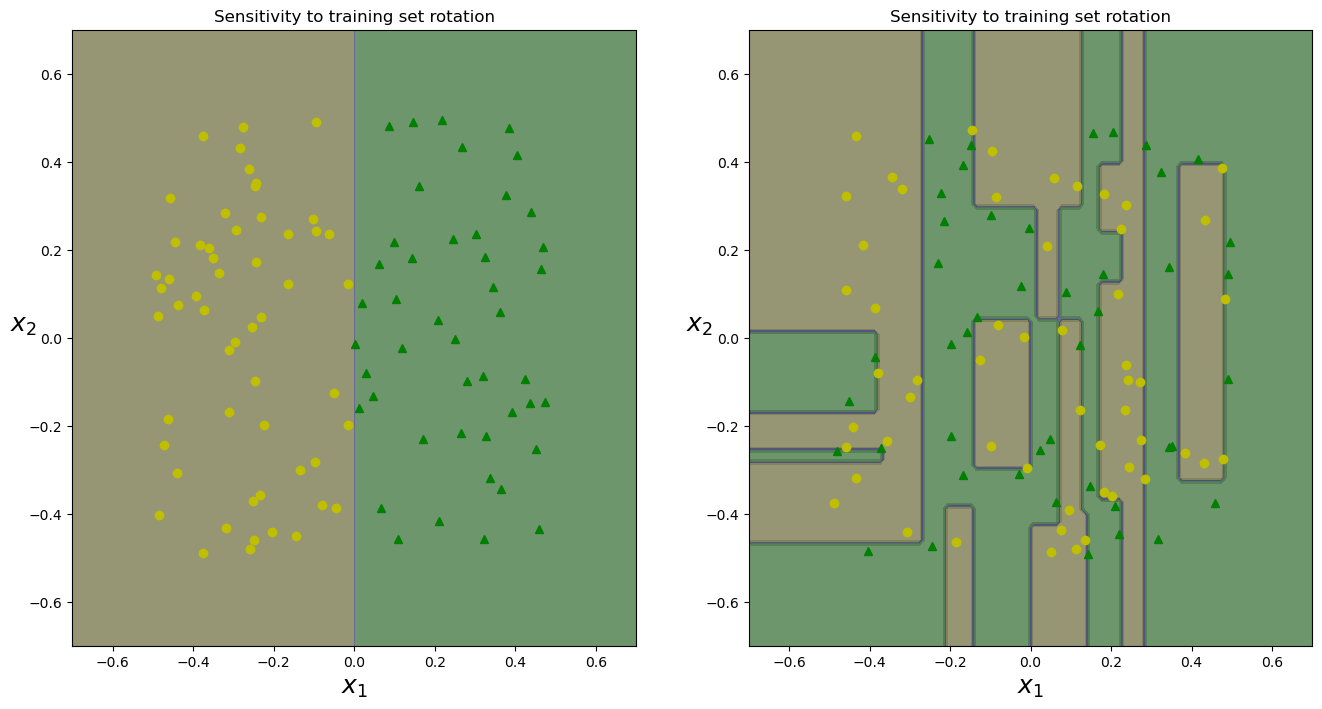

In [31]:
np.random.seed(6)
Xs = np.random.rand(100, 2) - 0.5
ys = (Xs[:, 0] > 0).astype(np.float32) * 2

## 矩阵旋转
angle = np.pi / 4
rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)],[np.sin(angle), np.cos(angle)]])
Xsr = Xs.dot(rotation_matrix)

tree_clf_s = DecisionTreeClassifier()
tree_clf_s.fit(Xs, ys)
tree_clf_sr = DecisionTreeClassifier()
tree_clf_sr.fit(Xsr, ys)

plt.figure(figsize=(16, 8), dpi=100)
plt.subplot(121)
plt.title('Sensitivity to training set rotation')
plot_decision_boundary(tree_clf_s, Xs, ys, axes=[-0.7, 0.7, -0.7, 0.7], iris=False)
plt.subplot(122)
plt.title('Sensitivity to training set rotation')
plot_decision_boundary(tree_clf_sr, Xsr, ys, axes=[-0.7, 0.7, -0.7, 0.7], iris=False)
plt.show()

### 结论: 决策树的数据的形状是非常敏感的

# 回归任务

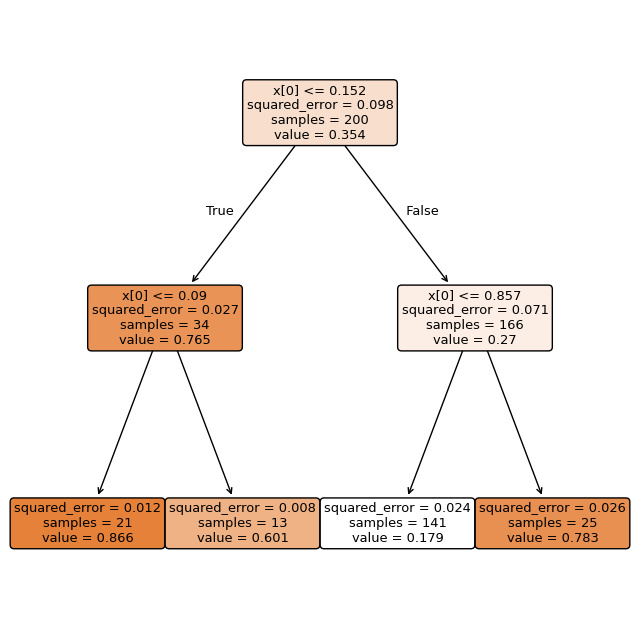

[[ 0.75741454]
 [ 0.15139395]
 [ 0.46158101]
 [ 0.9471989 ]
 [ 0.67258846]
 [-0.04435698]
 [ 0.08181934]
 [-0.02297292]
 [ 0.02637371]
 [ 0.07391541]
 [ 0.00733337]
 [ 0.30982802]
 [ 0.02915293]
 [-0.0178793 ]
 [ 0.07850315]
 [ 0.90443052]
 [ 0.37687117]
 [ 0.15674665]
 [ 0.60766573]
 [ 0.381943  ]
 [ 0.76195523]
 [ 0.13188938]
 [ 0.34646245]
 [ 0.0749132 ]
 [ 0.2361338 ]
 [-0.0202811 ]
 [ 0.63227691]
 [ 0.93389752]
 [ 0.06894594]
 [ 0.21900003]
 [ 0.0665776 ]
 [ 1.05924523]
 [ 0.32254544]
 [-0.02042175]
 [-0.0553342 ]
 [ 0.29806169]
 [ 0.77250824]
 [ 0.29091741]
 [ 0.2944741 ]
 [ 0.13093218]
 [ 0.23465303]
 [ 0.15597391]
 [-0.10972981]
 [ 0.68727746]
 [ 0.12137066]
 [ 0.14310757]
 [ 0.12534991]
 [ 0.80261443]
 [-0.10539308]
 [ 0.45091641]
 [ 0.32760607]
 [ 0.35456007]
 [ 0.21641512]
 [ 0.14608677]
 [ 0.20201222]
 [ 0.25434917]
 [ 0.29973934]
 [ 0.1495871 ]
 [ 0.5002537 ]
 [-0.00798137]
 [ 0.45660844]
 [ 0.80154865]
 [ 0.40095953]
 [ 0.5211859 ]
 [ 0.17479001]
 [ 0.17137273]
 [ 0.08577

In [58]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

np.random.seed(6)
m = 200
X = np.random.rand(m, 1)
y = 4*(X-0.5)**2
y = y + np.random.randn(m, 1)/10

tree = DecisionTreeRegressor(max_depth=2)
tree.fit(X, y)
plt.figure(figsize=(8, 8))
plot_tree(tree, filled=True, rounded=True)
plt.show()

print(y)

# 上面的决策树
- value代表的是当前样本y的平均值
- squared_error代表当前样本的均方误差

## 回归任务,不再采用gini系数作为评估,而是采用mse均方误差,且sklearn采用的是二叉树

In [75]:
tree_reg1 = DecisionTreeRegressor()
tree_reg1.fit(X, y)
tree_reg2 = DecisionTreeRegressor(max_depth=4)
tree_reg2.fit(X, y)

DecisionTreeRegressor(max_depth=4)

In [76]:
def plot_regression_predictions(tree, X, y, axes=[0, 1, -0.2, 1], ylable="$y$"):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$", fontsize=14)
    if ylable:
        plt.ylabel(ylable, fontsize=14, rotation=0)
    plt.plot(X, y, "b.")
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")
    plt.legend(loc="best", fontsize=14)


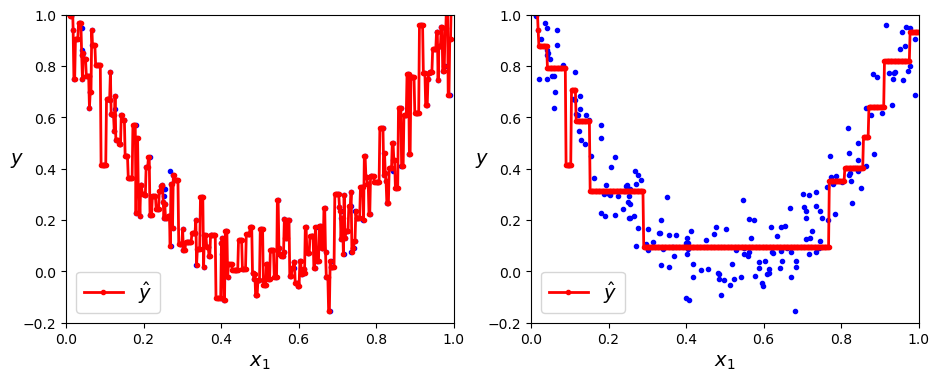

In [77]:
plt.figure(figsize=(11, 4))
plt.subplot(121)
plot_regression_predictions(tree_reg1, X, y)
plt.subplot(122)
plot_regression_predictions(tree_reg2, X, y)

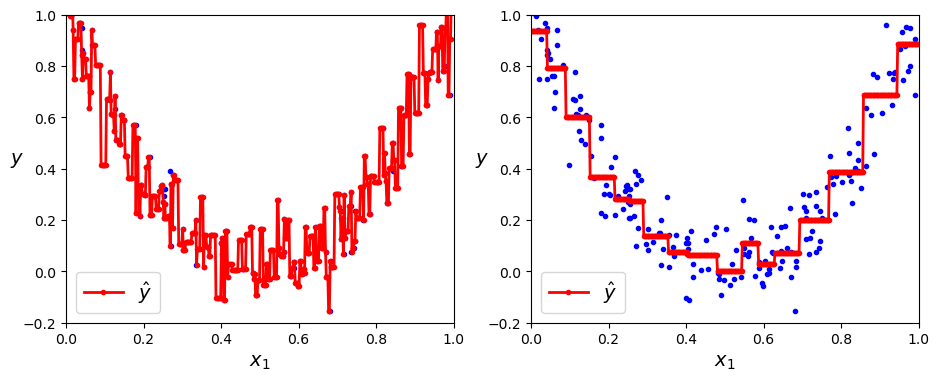

In [74]:
tree_reg1 = DecisionTreeRegressor()
tree_reg1.fit(X, y)
tree_reg2 = DecisionTreeRegressor(min_samples_leaf=10)
tree_reg2.fit(X, y)
plt.figure(figsize=(11, 4))
plt.subplot(121)
plot_regression_predictions(tree_reg1, X, y)
plt.subplot(122)
plot_regression_predictions(tree_reg2, X, y)